**<h3 style="color:orange">Please make sure any LLM coding assistant like Github Copilot or Cursus is turned OFF!</h2>**

**<h4 style="color:orange">We want you to learn and think critically, not to let LLMs do your work for you.</h4>**

**<h4 style="color:orange">Ask your group members or the internet for help, BEFORE asking your favorite chatbot.</h4>**

<img src="../figures/copilot.png">

# Assignment 1 Part 2: Modelling Boids as a Lagrangian System


In [2]:
# Import all the required libraries here
import torch as T
from torch import nn
from torch.utils.data import Dataset, Subset
from torch_geometric.data import Data, DataLoader as GraphDataLoader
import lightning as L
import os
import pickle
import matplotlib.pyplot as plt


print(f"Success! Running PyTorch {T.__version__} and Lightning {L.__version__}")
cuda_available = T.cuda.is_available()
if cuda_available:
    print(f"CUDA is available! Device count: {T.cuda.device_count()}")
else:
    print("CUDA is not available.")

W0925 08:00:03.174000 24976 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Success! Running PyTorch 2.11.0+cu128 and Lightning 2.6.6
CUDA is available! Device count: 1


In [3]:
class BoidsDataset(Dataset):
    """Dataset for the Boids simulation data."""

    def __init__(self, path):
        self.path = path
        self.nodes = T.tensor([], dtype=T.float32)  
        self.edge_index = T.tensor([], dtype=T.long)
        self.edge_attributes = T.tensor([], dtype=T.float32) 
        self.n_simulations = 0
        self.traj_length = 0

    def load_data(self):
        if not os.path.exists(self.path):
            raise FileNotFoundError(
                f"Data file not found at {self.path}. Please check the path and try again."
            )
        with open(self.path, "rb") as f:
            data = pickle.load(f)

        # DONE: Implement the logic to load nodes and edges from the data dictionary 

        positions = T.stack([T.tensor(sim, dtype=T.float32) for sim in data])
        velocities = T.diff(positions, dim=1)
        positions = positions[:, 1:]
        next_velocities = T.cat([velocities[:, 1:], velocities[:, -1:]], dim=1)
        self.nodes = T.cat([positions, velocities, velocities.norm(dim=-1, keepdim=True), next_velocities], dim=-1)

        RADIUS = 2.0
        edge_index = []
        edge_attributes = []
        for sim in positions:
            sim_edges = []
            sim_attributes = []
            for frame in sim:
                sq_dists = T.cdist(frame, frame) ** 2
                neighbours = (sq_dists < RADIUS ** 2).fill_diagonal_(False)
                edges = neighbours.nonzero().T
                sim_edges.append(edges)
                sim_attributes.append(sq_dists[edges[0], edges[1]].unsqueeze(-1))
            edge_index.append(sim_edges)
            edge_attributes.append(sim_attributes)
        self.edge_index = edge_index
        self.edge_attributes = edge_attributes

        self.n_simulations = self.nodes.shape[0]
        self.traj_length = self.nodes.shape[1] - 1

        # DONE

        print(
            f"\nLoaded data from {self.path}, containing {len(data)} samples of shape {data[0].shape}\n"
        )

class BoidsTrajectoryDataset(BoidsDataset):
    """One sample = one full trajectory: nodes has shape (traj_len, ...)."""

    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        return Data(
            x=self.nodes[idx],
            edge_index=self.edge_index[idx],
            edge_attr=self.edge_attributes[idx]
        )


class BoidsStepDataset(BoidsDataset):
    """One sample = one timestep: nodes has shape (...)."""

    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length
        return Data(
            x=self.nodes[sim_idx][t_idx],
            edge_index=self.edge_index[sim_idx][t_idx],
            edge_attr=self.edge_attributes[sim_idx][t_idx]
        )

class DataModule(L.LightningDataModule):
    """Lightning DataModule class that manages the dataset splitting and the dataloaders"""

    def __init__(self, dataset, batch_size, train_split, val_split, seed=42):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.train_split = train_split
        self.val_split = val_split
        self.seed = seed

    def prepare_data(self):
        self.dataset.load_data()

    def setup(self, stage=None):
            if getattr(self, "train_set", None) is not None:
                return

            # DONE: Implement logic to split the dataset into train, validation, and test sets

            train_size = int(len(self.dataset) * self.train_split)
            val_size = int(len(self.dataset) * self.val_split)
            indices = list(range(len(self.dataset)))

            self.train_set = Subset(self.dataset, indices[:train_size])
            self.val_set = Subset(self.dataset, indices[train_size : train_size + val_size])
            self.test_set = Subset(self.dataset, indices[train_size + val_size :])


            #DONE

    def train_dataloader(self):
        return GraphDataLoader(self.train_set, batch_size=self.batch_size)

    def val_dataloader(self):
        return GraphDataLoader(self.val_set, batch_size=self.batch_size)

    def test_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

    def predict_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

path = os.path.join(os.getcwd(), "..", "data","boids_dataset.pkl")
boids_dataset = BoidsTrajectoryDataset(path=path)
boids_dataset.load_data()


Loaded data from c:\Users\Sujitha\ml4sci-2026\assignments\..\data\boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)



positions range 0.5684 to 24.4844
speed mean 1.4922 std 0.0199
acceleration mean 0.3591 = 24% of |v|
isolated boids t=1 70% t=49 0%
speed near wall 1.4186 vs away 1.4935


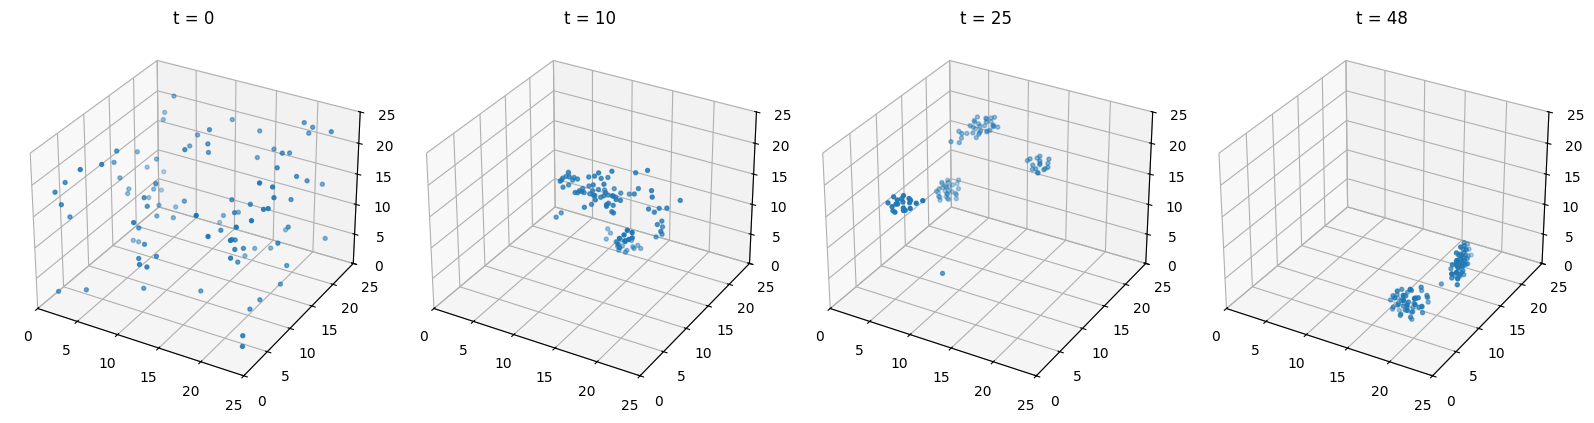

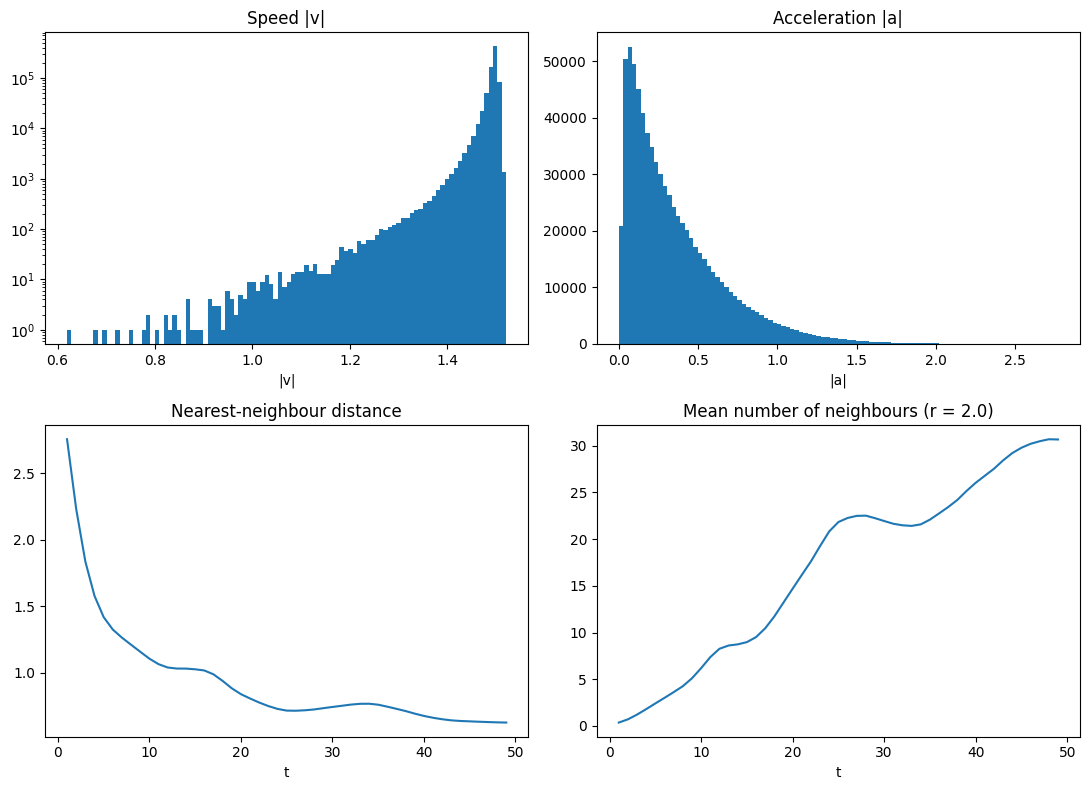

In [6]:
# Perform the exploratory data analysis here

sim = boids_dataset.nodes[0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': '3d'})
for ax, t in zip(axes, [0, 10, 25, 48]):
    ax.scatter(sim[t, :, 0], sim[t, :, 1], sim[t, :, 2], s=8)
    ax.set(title=f't = {t}', xlim=(0, 25), ylim=(0, 25), zlim=(0, 25))
plt.tight_layout()

X = boids_dataset.nodes[:int(0.8 * boids_dataset.n_simulations)][::10]
P = X[..., :3]
V = X[..., 3:6]
speed = V.norm(dim=-1)
acc = (X[:, :-1, :, 7:10] - X[:, :-1, :, 3:6]).norm(dim=-1)
wall_dist = T.minimum(P, 25 - P).min(-1).values
near_wall = wall_dist < 2

CUTOFF = 2.0
frames = range(1, P.shape[1] + 1)
nn_dist = []
degree = []
isolated = []
for t in range(P.shape[1]):
    D = T.cdist(P[:, t], P[:, t])
    D.diagonal(dim1=-2, dim2=-1)[:] = 1e9
    k = (D < CUTOFF).sum(-1).float()
    nn_dist.append(D.min(-1).values.mean())
    degree.append(k.mean())
    isolated.append(k.eq(0).float().mean() * 100)

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].hist(speed.flatten().numpy(), bins=100)
ax[0, 0].set(title='Speed |v|', xlabel='|v|', yscale='log')
ax[0, 1].hist(acc.flatten().numpy(), bins=100)
ax[0, 1].set(title='Acceleration |a|', xlabel='|a|')
ax[1, 0].plot(frames, nn_dist)
ax[1, 0].set(title='Nearest-neighbour distance', xlabel='t')
ax[1, 1].plot(frames, degree)
ax[1, 1].set(title=f'Mean number of neighbours (r = {CUTOFF})', xlabel='t')
plt.tight_layout()

print(f"positions range {P.min():.4f} to {P.max():.4f}")
print(f"speed mean {speed.mean():.4f} std {speed.std():.4f}")
print(f"acceleration mean {acc.mean():.4f} = {100 * acc.mean() / speed.mean():.0f}% of |v|")
print(f"isolated boids t=1 {isolated[0]:.0f}% t=49 {isolated[-1]:.0f}%")
print(f"speed near wall {speed[near_wall].mean():.4f} vs away {speed[~near_wall].mean():.4f}")


In [6]:
class EGNNLayer(nn.Module):
    
    def __init__(self, node_dim, edge_dim, hidden_dim, C=1.0):
        super().__init__()
        self.C = C
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1 + edge_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        self.velocity_mlp = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1, bias=False),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, node_dim),
        )
        nn.init.xavier_uniform_(self.coord_mlp[-1].weight, gain=0.001)
        nn.init.zeros_(self.velocity_mlp[-1].weight)
        nn.init.ones_(self.velocity_mlp[-1].bias)

    def forward(self, h, x, v, edge_index, edge_attr):
        src, dst = edge_index
        rel = x[src] - x[dst]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)
        m = self.edge_mlp(T.cat([h[src], h[dst], dist2, edge_attr], dim=-1))
        agg = h.new_zeros(h.shape[0], m.shape[-1])
        agg.index_add_(0, dst, m)
        h_new = self.node_mlp(T.cat([h, agg], dim=-1))
        interaction = v.new_zeros(v.shape)
        interaction.index_add_(0, dst, rel * self.coord_mlp(m))
        v_new = self.velocity_mlp(h) * v + self.C * interaction
        x_new = x + v_new
        return h_new, x_new, v_new


class EGNN(nn.Module):

    def __init__(self, input_dim=1, hidden_dim=64, edge_dim=1, n_layers=4):
        super().__init__()
        self.node_in = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            EGNNLayer(node_dim=hidden_dim, edge_dim=edge_dim, hidden_dim=hidden_dim)
            for _ in range(n_layers)
        ])

    def forward(self, x, edge_index, edge_attr):
        positions = x[..., :3]
        velocities = x[..., 3:6]
        h = self.node_in(x[..., 6:7])
        for layer in self.layers:
            h, positions, velocities = layer(h, positions, velocities, edge_index, edge_attr)
        return velocities


In [11]:
def build_radius_graph(positions, radius=2.0):
        sq_dists = T.cdist(positions, positions) ** 2
        neighbours = (sq_dists < radius ** 2)
        neighbours.fill_diagonal_(False)
        edge_index = neighbours.nonzero().T
        edge_attr = sq_dists[edge_index[0], edge_index[1]].unsqueeze(-1)
        return edge_index, edge_attr

In [16]:
class BoidsModel(L.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x, edge_index, edge_attr):
        return self.model(x, edge_index, edge_attr)

    def _step(self, batch):

        # TODO Implement the logic for a single training/validation step here
        inputs = batch.x[..., :7]      
        targets = batch.x[..., 7:10]   

        predictions = self(inputs, batch.edge_index, batch.edge_attr)

        loss = nn.functional.mse_loss(predictions, targets)

        # DONE
        return loss
        

    def training_step(self, batch):
        loss = self._step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch):
        loss = self._step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch):

        # TODO Implement the logic for autoregressive rollout here
        MAX_SPEED = 5.0

        n_frames = batch.x.shape[0]

        rollout = T.zeros_like(batch.x[..., :7])
        rollout[0] = batch.x[0, :, :7]

        edge_index, edge_attr = build_radius_graph(rollout[0, :, :3])

        for t in range(n_frames - 1):
            model_input = rollout[t]

            new_velocities = self(model_input, edge_index, edge_attr)
            speed = new_velocities.norm(dim=-1, keepdim=True).clamp(min=1e-8)
            scale = T.clamp(speed, max=MAX_SPEED) / speed
            new_velocities = new_velocities * scale

            new_positions = model_input[:, :3] + new_velocities
            new_speed = new_velocities.norm(dim=-1, keepdim=True)

            rollout[t + 1] = T.cat([new_positions, new_velocities, new_speed], dim=-1)

            edge_index, edge_attr = build_radius_graph(new_positions)

        return rollout

    def configure_optimizers(self):
        return T.optim.Adam(self.parameters(), lr=self.learning_rate)

class LossHistory(L.Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get("train_loss").item())
    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(trainer.callback_metrics.get("val_loss").item())

In [8]:
BATCH_SIZE = 32
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
MAX_EPOCHS = 15
LEARNING_RATE = 1e-3

# Initialize dataset
dataset = BoidsStepDataset(path)

# Initialize datamodule
datamodule = DataModule(dataset, batch_size=BATCH_SIZE, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

# Initialize model
egnn = EGNN()
model = BoidsModel(egnn)

# Initialize trainer
loss_history = LossHistory()
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    callbacks=[loss_history],
    gradient_clip_val=1.0,
    logger=False,
    enable_checkpointing=False)

# Fit the model to the dataset
trainer.fit(model, datamodule=datamodule)

# Load the inference dataset 
traj_dataset = BoidsTrajectoryDataset(path)
predict_datamodule = DataModule(traj_dataset, batch_size=1, train_split=TRAIN_SPLIT, val_split=VAL_SPLIT)

# Perform inference
rollouts = trainer.predict(model, datamodule=predict_datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Loaded data from c:\Users\Sujitha\ml4sci-2026\assignments\..\data\boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)



┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ EGNN │  133 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 133 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 133 K                                                                                                
Total estimated model params size (MB): 0.535                                                                      
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

`Trainer.fit` stopped: `max_epochs=15` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Loaded data from c:\Users\Sujitha\ml4sci-2026\assignments\..\data\boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)



c:\Users\Sujitha\anaconda3\envs\MLEassign\Lib\site-packages\lightning\fabric\utilities\data.py:257: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
c:\Users\Sujitha\anaconda3\envs\MLEassign\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


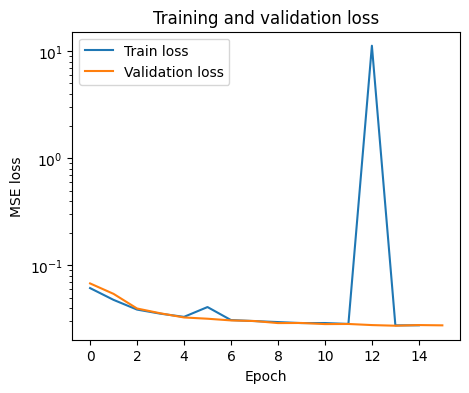

C:\Users\Sujitha\AppData\Local\Temp\ipykernel_24976\1139691298.py:123: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  return GraphDataLoader(self.test_set, batch_size=self.batch_size)


Ground truth shape: (400, 49, 100, 3)
Predicted shape:    (400, 49, 100, 3)
Finite frames per timestep: [400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400 400
 400 400 400 400 400 400 400 400 400 400 400 400 400]
Average Displacement Error (ADE): 95.4864
Final Displacement Error (FDE):   210.8299


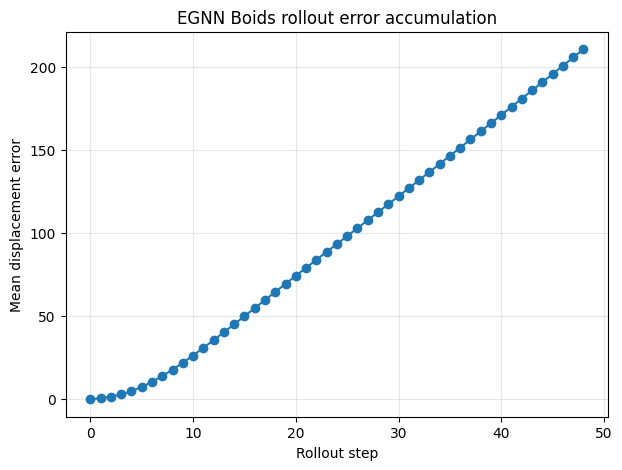

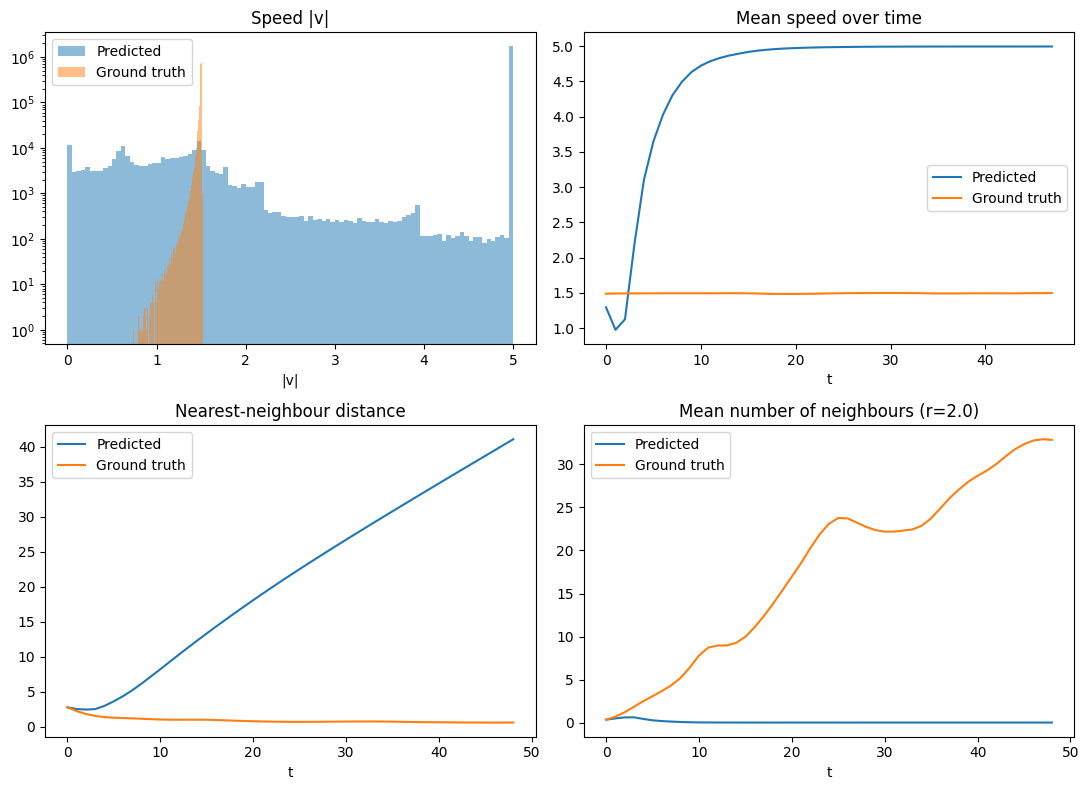

Isolated boids at t=0: predicted 71%, ground truth 71%
Isolated boids at t=end: predicted 99%, ground truth 0%


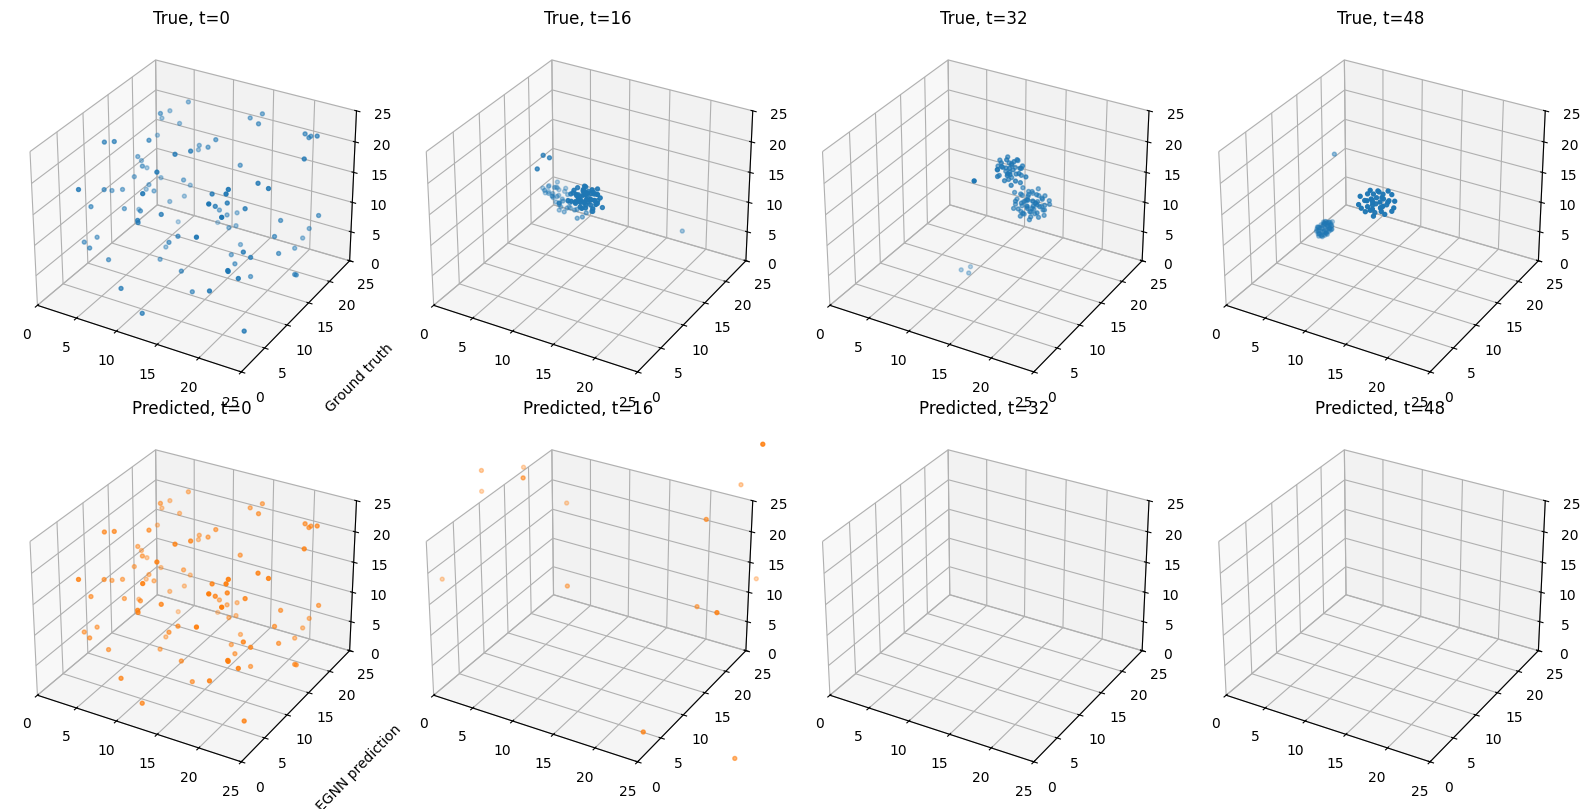

In [19]:
# Evaluate the model and make plots here
import numpy as np

BOX_SIZE = 25.0
RADIUS = 2.0

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(loss_history.train_loss, label='Train loss', color='tab:blue')
ax.plot(loss_history.val_loss, label='Validation loss', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.legend()
ax.set_title('Training and validation loss')
plt.show()

predict_loader = predict_datamodule.predict_dataloader()

ground_truth_positions = T.stack(
    [batch.x[..., :3] for batch in predict_loader], dim=0
).numpy()

predicted_positions = T.stack(
    [rollout[..., :3] for rollout in rollouts], dim=0
).numpy()

print("Ground truth shape:", ground_truth_positions.shape)
print("Predicted shape:   ", predicted_positions.shape)

n_finite = np.isfinite(predicted_positions).all(axis=(2, 3)).sum(axis=0)
print("Finite frames per timestep:", n_finite)

def safe_hist(ax, values, **kwargs):
    values = values[np.isfinite(values)]
    ax.hist(values, **kwargs)

displacement_errors = np.linalg.norm(predicted_positions - ground_truth_positions, axis=-1)

ADE = np.nanmean(np.where(np.isfinite(displacement_errors), displacement_errors, np.nan))
FDE = np.nanmean(np.where(np.isfinite(displacement_errors[:, -1]), displacement_errors[:, -1], np.nan))
DE_over_time = np.nanmean(np.where(np.isfinite(displacement_errors), displacement_errors, np.nan), axis=(0, 2))

print(f"Average Displacement Error (ADE): {ADE:.4f}")
print(f"Final Displacement Error (FDE):   {FDE:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(DE_over_time, marker='o')
plt.xlabel('Rollout step')
plt.ylabel('Mean displacement error')
plt.title('EGNN Boids rollout error accumulation')
plt.grid(alpha=0.3)
plt.show()


def compute_boids_stats(positions, radius=RADIUS):
    positions_t = T.from_numpy(positions)
    velocities = T.diff(positions_t, dim=1)
    speed = velocities.norm(dim=-1)

    n_frames = positions_t.shape[1]
    nn_dist, degree, isolated = [], [], []
    for t in range(n_frames):
        P_t = positions_t[:, t]
        D = T.cdist(P_t, P_t)
        D.diagonal(dim1=-2, dim2=-1)[:] = 1e9
        k = (D < radius).sum(-1).float()
        nn_dist.append(D.min(-1).values.mean().item())
        degree.append(k.mean().item())
        isolated.append((k.eq(0).float().mean() * 100).item())

    return {
        "speed": speed.numpy(),
        "mean_speed_over_time": speed.mean(dim=(0, 2)).numpy(),
        "nn_dist": np.array(nn_dist),
        "degree": np.array(degree),
        "isolated_pct": np.array(isolated),
    }

pred_stats = compute_boids_stats(predicted_positions)
gt_stats = compute_boids_stats(ground_truth_positions)

fig, axs = plt.subplots(2, 2, figsize=(11, 8))

safe_hist(axs[0, 0], pred_stats["speed"].flatten(), bins=100, alpha=0.5, label="Predicted")
safe_hist(axs[0, 0], gt_stats["speed"].flatten(), bins=100, alpha=0.5, label="Ground truth")
axs[0, 0].set(title='Speed |v|', xlabel='|v|', yscale='log')
axs[0, 0].legend()

axs[0, 1].plot(pred_stats["mean_speed_over_time"], label="Predicted")
axs[0, 1].plot(gt_stats["mean_speed_over_time"], label="Ground truth")
axs[0, 1].set(title='Mean speed over time', xlabel='t')
axs[0, 1].legend()

axs[1, 0].plot(pred_stats["nn_dist"], label="Predicted")
axs[1, 0].plot(gt_stats["nn_dist"], label="Ground truth")
axs[1, 0].set(title='Nearest-neighbour distance', xlabel='t')
axs[1, 0].legend()

axs[1, 1].plot(pred_stats["degree"], label="Predicted")
axs[1, 1].plot(gt_stats["degree"], label="Ground truth")
axs[1, 1].set(title=f'Mean number of neighbours (r={RADIUS})', xlabel='t')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Isolated boids at t=0: predicted {pred_stats['isolated_pct'][0]:.0f}%, "
      f"ground truth {gt_stats['isolated_pct'][0]:.0f}%")
print(f"Isolated boids at t=end: predicted {pred_stats['isolated_pct'][-1]:.0f}%, "
      f"ground truth {gt_stats['isolated_pct'][-1]:.0f}%")

sim_idx = 0
times = [0, predicted_positions.shape[1] // 3, 2 * predicted_positions.shape[1] // 3,
         predicted_positions.shape[1] - 1]

fig, axes = plt.subplots(2, len(times), figsize=(4 * len(times), 8),
                          subplot_kw={'projection': '3d'})

for j, t in enumerate(times):
    axes[0, j].scatter(*ground_truth_positions[sim_idx, t].T, s=8, color='tab:blue')
    axes[0, j].set(title=f'True, t={t}', xlim=(0, BOX_SIZE), ylim=(0, BOX_SIZE), zlim=(0, BOX_SIZE))

    axes[1, j].scatter(*predicted_positions[sim_idx, t].T, s=8, color='tab:orange')
    axes[1, j].set(title=f'Predicted, t={t}', xlim=(0, BOX_SIZE), ylim=(0, BOX_SIZE), zlim=(0, BOX_SIZE))

axes[0, 0].set_ylabel('Ground truth', labelpad=20)
axes[1, 0].set_ylabel('EGNN prediction', labelpad=20)
plt.tight_layout()
plt.show()